# 📈 TradeTutor — 트레이딩 학습 에이전트 (LangGraph)

> 교육 & 학습 테마 · 데모데이 프로젝트 · **Step 1 설계 + Step 2 LangGraph 기초 구축**

## Step 1. 에이전트 설계

**이름**: TradeTutor (트레이드튜터)

**목적**
초보 트레이더가 매주 새로운 매매법을 **명확한 진입/청산 규칙**으로 배우고,
**실제 코인 데이터로 백테스트**하며 스스로 검증하고, 튜터의 **코칭 피드백**으로 학습하도록 돕는다.
⚠️ 투자 조언·매매 신호가 아니라 **학습·검증 도구**다.

**핵심 기능 (3+)**
1. **전략 리서치** — 유명 전략을 명확한 규칙(진입/청산/원리/주의점)으로 정리
2. **백테스트** — 실제 상위 코인 데이터에 규칙 적용 → 수익률·승률·MDD + 매매시점 시각화
3. **학습 코칭** — 백테스트 결과 해석 + 강점/약점 + 다음 실험 제안
4. *(확장 예정)* 전략 라이브러리 매주 업데이트, 웹/유튜브 리서치, 자동매매 개념 학습

**내장 전략 5개** (유명·검증된 것부터, 이후 매주 추가)
골든/데드 크로스 · RSI · MACD · 볼린저 밴드 · 돌파(Donchian)

**데이터**: 실제 상위 5개 코인 — BTC · ETH · BNB · SOL · XRP (Binance 공개 API, 키 불필요)

**모델 선택 (효율)**: 잘 정의된 작업이라 저렴·빠른 `gpt-4o-mini` 를 워크호스로 사용.
더 깊은 리서치가 필요하면 `gpt-4o` / Claude 로 노드별 승급 가능.

### 그래프 구조 (노드 & 엣지)

```mermaid
graph TD
    A([사용자 입력<br/>전략 + 코인]) --> R[research 노드<br/>전략 규칙 정리]
    R --> B[backtest 노드<br/>실데이터 백테스트]
    B --> C[coach 노드<br/>학습 피드백]
    C --> Z([완료])
```

이번 주는 **linear 3-노드**. 다음 주부터 router 분기(학습/검증/질문) + 웹·유튜브 리서치 노드 + 시각화 노드로 확장.

**State** (커스텀): `messages`(대화) · `strategy_key` · `symbol` · `strategy_rules` · `backtest_result` · `coaching`

---
## Step 2. LangGraph 기초 구축


### 0) 준비
```bash
uv sync            # 의존성 설치
# .env 에 OPENAI_API_KEY=sk-... 설정
uv run jupyter notebook assignment12.ipynb
```

In [1]:
import dotenv
dotenv.load_dotenv()  # .env 의 OPENAI_API_KEY 로드

from typing import TypedDict, Annotated
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

# 한글 차트 폰트 (macOS)
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
print("준비 완료")

Matplotlib is building the font cache; this may take a moment.


준비 완료


In [2]:
# ---------- 기술적 지표 ----------
def _sma(s, n): return s.rolling(n).mean()
def _ema(s, n): return s.ewm(span=n, adjust=False).mean()

def _rsi(c, n=14):
    d = c.diff()
    up = d.clip(lower=0).ewm(alpha=1/n, adjust=False).mean()
    dn = (-d.clip(upper=0)).ewm(alpha=1/n, adjust=False).mean()
    rs = up / dn.replace(0, np.nan)
    return 100 - 100 / (1 + rs)

def _hold(entry, exit):
    """진입 신호에서 매수, 청산 신호에서 매도, 그 사이엔 보유(1)."""
    e, x = entry.fillna(False), exit.fillna(False)
    pos = pd.Series(0, index=entry.index)
    h = 0
    for i in range(len(pos)):
        if h == 0 and e.iloc[i]:
            h = 1
        elif h == 1 and x.iloc[i]:
            h = 0
        pos.iloc[i] = h
    return pos

In [3]:
# ---------- 5개 전략 (position 시계열 반환: 1=보유, 0=현금) ----------
def sig_sma_cross(df, fast=20, slow=50):
    f, s = _sma(df.close, fast), _sma(df.close, slow)
    return ((f > s) & f.notna() & s.notna()).astype(int)

def sig_rsi(df, n=14, low=30, high=70):
    r = _rsi(df.close, n)
    return _hold(r < low, r > high)

def sig_macd(df, fast=12, slow=26, sig=9):
    m = _ema(df.close, fast) - _ema(df.close, slow)
    sg = _ema(m, sig)
    pos = (m > sg).astype(int); pos[m.isna() | sg.isna()] = 0
    return pos

def sig_bollinger(df, n=20, k=2):
    ma, sd = _sma(df.close, n), df.close.rolling(n).std()
    return _hold(df.close < (ma - k*sd), df.close > ma)

def sig_breakout(df, n=20):
    hi = df.close.rolling(n).max().shift(1)
    lo = df.close.rolling(n).min().shift(1)
    return _hold(df.close > hi, df.close < lo)

STRATEGY_LIBRARY = {
    "sma_cross": {"name": "골든/데드 크로스 (SMA 20/50)",
        "desc": "단기 이동평균이 장기 이동평균을 상향 돌파하면 매수(골든크로스), 하향 돌파하면 매도(데드크로스). 대표적 추세추종.",
        "signal": sig_sma_cross},
    "rsi": {"name": "RSI 과매도/과매수 (14, 30/70)",
        "desc": "RSI가 30 아래(과매도)면 매수, 70 위(과매수)면 매도. 대표적 역추세(평균회귀).",
        "signal": sig_rsi},
    "macd": {"name": "MACD 시그널 크로스 (12/26/9)",
        "desc": "MACD선이 시그널선을 상향 돌파하면 매수, 하향 돌파하면 매도. 추세+모멘텀.",
        "signal": sig_macd},
    "bollinger": {"name": "볼린저 밴드 (20, 2σ)",
        "desc": "가격이 하단밴드 아래로 가면 매수, 중심선(이평) 회복 시 매도. 평균회귀.",
        "signal": sig_bollinger},
    "breakout": {"name": "돌파 (Donchian 20일)",
        "desc": "최근 20일 고가를 돌파하면 매수, 20일 저가를 이탈하면 매도. 추세추종.",
        "signal": sig_breakout},
}

TOP5 = ["BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT"]
print("전략:", list(STRATEGY_LIBRARY))
print("코인:", TOP5)

전략: ['sma_cross', 'rsi', 'macd', 'bollinger', 'breakout']
코인: ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT']


In [4]:
# ---------- 실제 코인 데이터 (Binance 공개 klines, 키 불필요) ----------
def fetch_ohlcv(symbol="BTCUSDT", interval="1d", limit=365):
    r = requests.get("https://api.binance.com/api/v3/klines",
                     params={"symbol": symbol, "interval": interval, "limit": limit}, timeout=20)
    r.raise_for_status()
    cols = ["open_time","open","high","low","close","volume",
            "close_time","qav","trades","tbav","tbqav","ignore"]
    df = pd.DataFrame(r.json(), columns=cols)
    df["date"] = pd.to_datetime(df["open_time"], unit="ms")
    for c in ["open","high","low","close","volume"]:
        df[c] = df[c].astype(float)
    return df[["date","open","high","low","close","volume"]].set_index("date")

_demo = fetch_ohlcv("BTCUSDT", "1d", 5)
_demo[["open","high","low","close"]]

,open,high,low,close
date,,,,
2026-07-04,62583.26,63461.99,62328.24,63144.01
2026-07-05,63144.01,63999.00,62436.59,63650.00
2026-07-06,63650.01,64700.00,61306.84,64042.02
2026-07-07,64042.93,64314.00,62671.39,63363.99
2026-07-08,63364.00,63761.99,61544.56,62225.27


In [5]:
# ---------- 백테스트 엔진 (롱온리, 익일 체결로 look-ahead 방지) ----------
def run_backtest(df, position):
    pos = position.shift(1).fillna(0)          # 신호 다음 날 체결
    ret = df.close.pct_change().fillna(0)
    equity = (1 + pos * ret).cumprod()         # 전략 자산 곡선
    bh = (1 + ret).cumprod()                   # 매수 후 보유
    dd = equity / equity.cummax() - 1
    c, p = df.close.values, pos.values
    trades, entry = [], None
    for i in range(len(p)):
        if entry is None and p[i] == 1:
            entry = i
        elif entry is not None and p[i] == 0:
            trades.append(c[i]/c[entry] - 1); entry = None
    if entry is not None:
        trades.append(c[-1]/c[entry] - 1)
    wins = [t for t in trades if t > 0]
    return {
        "total_return": float(equity.iloc[-1] - 1),
        "bh_return": float(bh.iloc[-1] - 1),
        "mdd": float(dd.min()),
        "n_trades": len(trades),
        "win_rate": float(len(wins)/len(trades)) if trades else 0.0,
        "equity": equity, "bh_equity": bh, "position": pos, "df": df,
    }

In [6]:
# ---------- LangGraph State (커스텀) ----------
class TradeTutorState(TypedDict):
    messages: Annotated[list, add_messages]   # 대화 누적 (add_messages 리듀서)
    strategy_key: str                          # 배울 전략
    symbol: str                                # 대상 코인
    strategy_rules: str                        # research 노드 결과
    backtest_result: dict                      # backtest 노드 결과
    coaching: str                              # coach 노드 결과

# 효율적 모델: 잘 정의된 작업엔 저렴·빠른 gpt-4o-mini 로 충분
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.3)

In [7]:
# ---------- 노드 1: research — 전략을 명확한 규칙으로 ----------
def research_node(state: TradeTutorState):
    strat = STRATEGY_LIBRARY[state["strategy_key"]]
    prompt = f"""너는 트레이딩 교육 튜터야. 학생에게 아래 매매 전략을 '명확한 규칙'으로 가르쳐.
전략: {strat['name']}
개요: {strat['desc']}

아래 형식으로 한국어로 간결히 정리해:
### 진입 규칙
### 청산 규칙
### 핵심 원리 (왜 작동하나)
### 주의점 (실패하는 상황)

이건 투자 조언이 아니라 '학습'임을 유지해."""
    resp = llm.invoke([SystemMessage(content="트레이딩 교육 튜터"), HumanMessage(content=prompt)])
    return {"strategy_rules": resp.content, "messages": [AIMessage(content=resp.content)]}

# ---------- 노드 2: backtest — 실데이터로 규칙 검증 (LLM 없음, 결정적) ----------
def backtest_node(state: TradeTutorState):
    key, symbol = state["strategy_key"], state["symbol"]
    df = fetch_ohlcv(symbol, "1d", 365)
    pos = STRATEGY_LIBRARY[key]["signal"](df)
    result = run_backtest(df, pos)
    result["symbol"] = symbol
    s = f"{symbol} · {STRATEGY_LIBRARY[key]['name']} → 전략 {result['total_return']:.1%} / 보유 {result['bh_return']:.1%} / MDD {result['mdd']:.1%} / {result['n_trades']}회 / 승률 {result['win_rate']:.0%}"
    return {"backtest_result": result, "messages": [AIMessage(content="📊 " + s)]}

# ---------- 노드 3: coach — 결과 해석 & 학습 피드백 ----------
def coach_node(state: TradeTutorState):
    r = state["backtest_result"]
    name = STRATEGY_LIBRARY[state["strategy_key"]]["name"]
    prompt = f"""학생이 {r['symbol']} 에 '{name}' 전략을 1년치로 백테스트했어.
결과: 전략수익률 {r['total_return']:.1%}, 매수후보유 {r['bh_return']:.1%}, 최대낙폭(MDD) {r['mdd']:.1%}, 매매 {r['n_trades']}회, 승률 {r['win_rate']:.0%}.

교육 튜터로서 한국어로:
1) 이 결과가 뭘 의미하는지 해석
2) 이 전략의 강점/약점
3) 다음에 실험해볼 것 (파라미터, 다른 코인 등)
투자 조언이 아니라 학습 관점으로."""
    resp = llm.invoke([SystemMessage(content="트레이딩 교육 튜터"), HumanMessage(content=prompt)])
    return {"coaching": resp.content, "messages": [AIMessage(content=resp.content)]}

In [8]:
# ---------- 그래프 연결: START → research → backtest → coach → END ----------
def build_graph():
    g = StateGraph(TradeTutorState)
    g.add_node("research", research_node)
    g.add_node("backtest", backtest_node)
    g.add_node("coach", coach_node)
    g.add_edge(START, "research")
    g.add_edge("research", "backtest")
    g.add_edge("backtest", "coach")
    g.add_edge("coach", END)
    return g.compile()

app = build_graph()
app.get_graph().print_ascii()   # 노드/엣지 다이어그램

+-----------+  
| __start__ |  
+-----------+  
      *        
      *        
      *        
+----------+   
| research |   
+----------+   
      *        
      *        
      *        
+----------+   
| backtest |   
+----------+   
      *        
      *        
      *        
  +-------+    
  | coach |    
  +-------+    
      *        
      *        
      *        
 +---------+   
 | __end__ |   
 +---------+   


In [9]:
# ---------- 백테스트 시각화: 매매시점 + 자산곡선 ----------
def plot_backtest(result, key):
    df, pos = result["df"], result["position"]
    chg = pos.diff().fillna(0)
    buys, sells = df.index[chg == 1], df.index[chg == -1]
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                                   gridspec_kw={"height_ratios": [2, 1]})
    ax1.plot(df.index, df.close, color="#3b6ea5", lw=1.2, label="종가")
    ax1.scatter(buys, df.close[buys], marker="^", color="#2ca02c", s=90, zorder=5, label="매수")
    ax1.scatter(sells, df.close[sells], marker="v", color="#d62728", s=90, zorder=5, label="매도")
    ax1.set_title(f"{result['symbol']} — {STRATEGY_LIBRARY[key]['name']}: 매매 시점")
    ax1.legend(loc="upper left"); ax1.grid(alpha=.3)
    ax2.plot(result["equity"].index, result["equity"], color="#3b6ea5", lw=1.5, label="전략")
    ax2.plot(result["bh_equity"].index, result["bh_equity"], color="#999", lw=1.2, ls="--", label="매수 후 보유")
    ax2.axhline(1, color="k", lw=.6)
    ax2.set_title("자산 곡선 (1 = 원금)"); ax2.legend(loc="upper left"); ax2.grid(alpha=.3)
    plt.tight_layout(); plt.show()

### 실행 예시 1 — 골든/데드 크로스 · BTC

그래프를 한 번 실행하면 `research → backtest → coach` 가 순서대로 돌며 State 를 채운다.

In [10]:
out1 = app.invoke({
    "messages": [HumanMessage(content="골든크로스 전략 배우고 싶어")],
    "strategy_key": "sma_cross",
    "symbol": "BTCUSDT",
})

print("─" * 60, "\n📘 전략 규칙 (research 노드)\n", "─" * 60)
print(out1["strategy_rules"])
r = out1["backtest_result"]
print("\n" + "─" * 60, "\n📊 백테스트 (backtest 노드)\n", "─" * 60)
print(f"{r['symbol']}  전략 {r['total_return']:.1%} | 매수후보유 {r['bh_return']:.1%} | "
      f"MDD {r['mdd']:.1%} | {r['n_trades']}회 | 승률 {r['win_rate']:.0%}")
print("\n" + "─" * 60, "\n🎓 학습 코칭 (coach 노드)\n", "─" * 60)
print(out1["coaching"])

──────────────────────────────────────────────────────────── 
📘 전략 규칙 (research 노드)
 ────────────────────────────────────────────────────────────
### 진입 규칙
1. **매수 (골든 크로스)**: 단기 이동평균(SMA 20)이 장기 이동평균(SMA 50)을 상향 돌파할 때 매수.
2. **매도 (데드 크로스)**: 단기 이동평균(SMA 20)이 장기 이동평균(SMA 50)을 하향 돌파할 때 매도.

### 청산 규칙
1. **매수 포지션 청산**: 단기 이동평균(SMA 20)이 장기 이동평균(SMA 50)을 하향 돌파할 때.
2. **매도 포지션 청산**: 단기 이동평균(SMA 20)이 장기 이동평균(SMA 50)을 상향 돌파할 때.

### 핵심 원리 (왜 작동하나)
골든 크로스와 데드 크로스는 시장의 추세 변화를 나타내는 신호로, 단기 이동평균이 장기 이동평균을 돌파할 때 매수 또는 매도의 신호로 해석됩니다. 이는 시장의 매수 또는 매도 압력이 변화하고 있음을 나타내며, 추세를 따라가는 전략으로 활용됩니다.

### 주의점 (실패하는 상황)
1. **횡보장**: 시장이 횡보할 때는 잘못된 신호가 발생할 수 있어 손실이 발생할 수 있습니다.
2. **지연 신호**: 이동평균은 과거 데이터를 기반으로 하므로 신호가 늦게 발생할 수 있어, 이미 큰 가격 변동이 일어난 후에 진입할 수 있습니다.
3. **거래량 부족**: 거래량이 적은 상황에서는 신뢰성이 떨어질 수 있습니다.

──────────────────────────────────────────────────────────── 
📊 백테스트 (backtest 노드)
 ────────────────────────────────────────────────────────────
BTCUSDT  전략 -14.3% | 매수후보유 -44.0% | MDD -28.5% | 4회 | 승률 50%

───

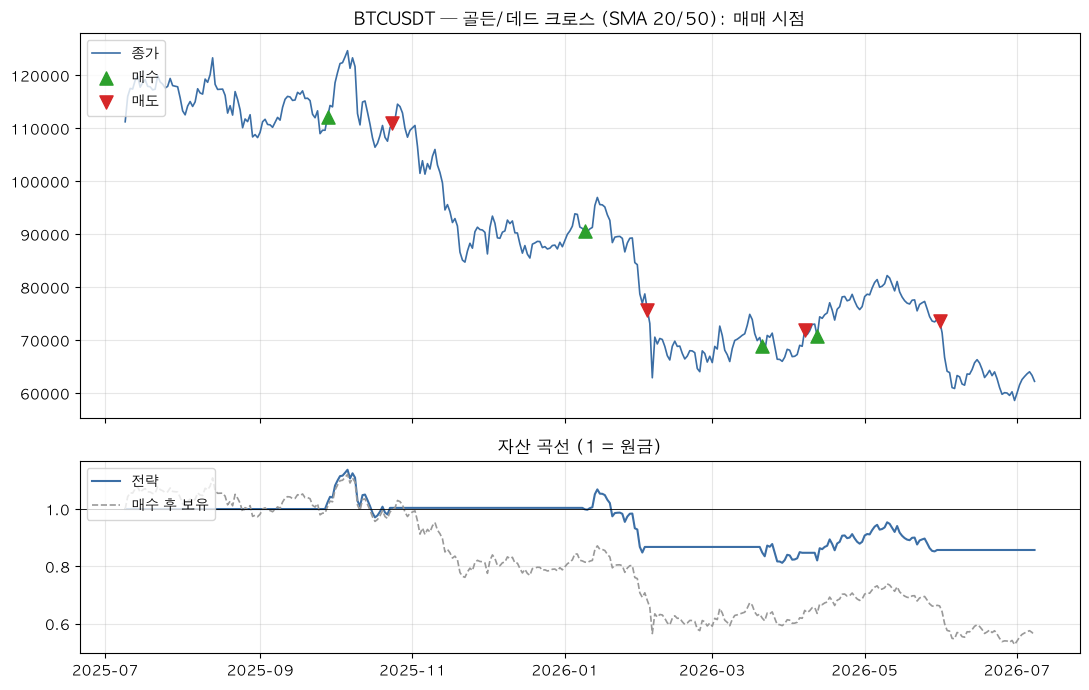

In [11]:
plot_backtest(out1["backtest_result"], "sma_cross")

### 실행 예시 2 — RSI 과매도/과매수 · ETH (다른 전략·코인)

ETHUSDT  전략 -47.1% | 매수후보유 -37.2% | MDD -56.2% | 1회 | 승률 0%

1) **결과 해석**:
   - **전략수익률 -47.1%**: 이 전략을 사용했을 때, 투자한 금액의 거의 절반이 손실이 발생했다는 의미입니다. 즉, 시장에서 이 전략이 효과적이지 않았음을 나타냅니다.
   - **매수후보유 -37.2%**: 매수 후 보유한 경우에도 손실이 발생했음을 보여줍니다. 이는 시장이 전반적으로 하락세였거나, 전략이 잘못 설정되었음을 시사합니다.
   - **최대낙폭(MDD) -56.2%**: 투자 자산의 가치가 최대 56.2%까지 하락했음을 의미합니다. 이는 투자자가 감당하기 어려운 수준의 손실로, 심리적 압박이 클 수 있습니다.
   - **매매 1회, 승률 0%**: 단 한 번의 거래만 이루어졌고, 그 거래가 모두 손실로 이어졌다는 것을 의미합니다. 이는 전략의 신뢰성을 더욱 낮추는 요소입니다.

2) **전략의 강점/약점**:
   - **강점**:
     - RSI는 과매도/과매수 신호를 제공하여 시장의 반전 가능성을 포착할 수 있는 도구입니다. 이론적으로는 유용한 지표입니다.
   - **약점**:
     - 이 전략은 단기적인 변동성에 취약할 수 있으며, 특히 강한 트렌드가 형성될 때 잘못된 신호를 줄 수 있습니다 ...


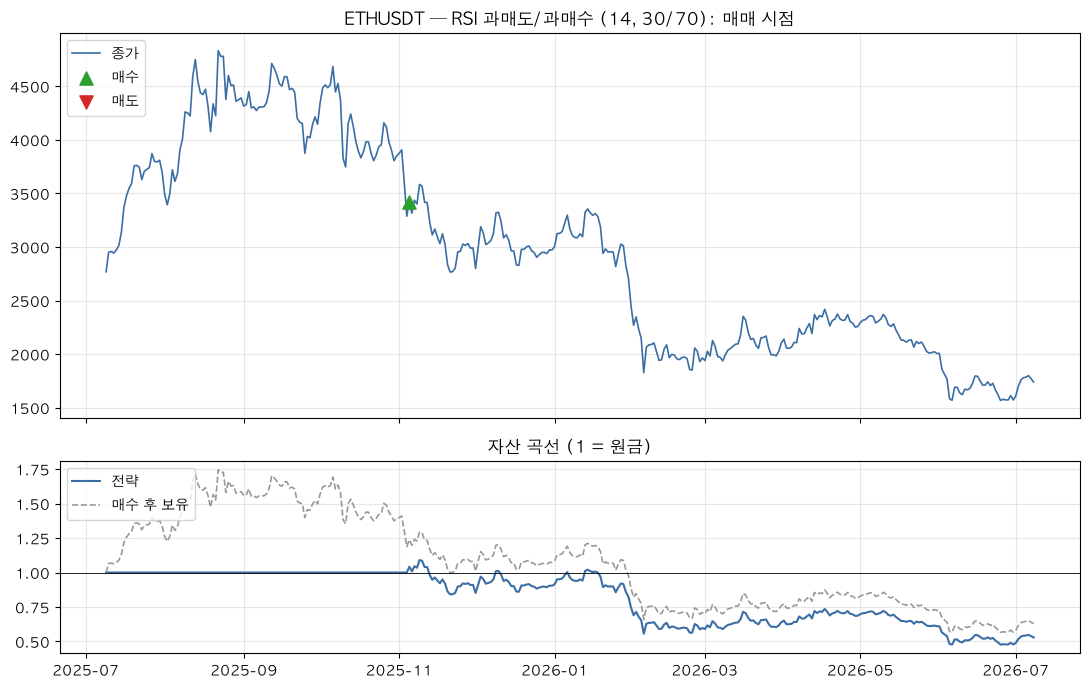

In [12]:
out2 = app.invoke({
    "messages": [HumanMessage(content="RSI 전략 알려줘")],
    "strategy_key": "rsi",
    "symbol": "ETHUSDT",
})
r = out2["backtest_result"]
print(f"{r['symbol']}  전략 {r['total_return']:.1%} | 매수후보유 {r['bh_return']:.1%} | "
      f"MDD {r['mdd']:.1%} | {r['n_trades']}회 | 승률 {r['win_rate']:.0%}\n")
print(out2["coaching"][:600], "...")
plot_backtest(out2["backtest_result"], "rsi")

### 5개 전략 한눈에 비교 (BTC, 최근 1년)

같은 코인에 5개 전략을 각각 백테스트해 성과를 비교한다. (학습용 — 어떤 전략이 어떤 장세에 맞는지 감 잡기)

In [13]:
rows = []
df_btc = fetch_ohlcv("BTCUSDT", "1d", 365)
for key, strat in STRATEGY_LIBRARY.items():
    res = run_backtest(df_btc, strat["signal"](df_btc))
    rows.append({
        "전략": strat["name"],
        "전략수익률": f"{res['total_return']:.1%}",
        "매수후보유": f"{res['bh_return']:.1%}",
        "MDD": f"{res['mdd']:.1%}",
        "매매횟수": res["n_trades"],
        "승률": f"{res['win_rate']:.0%}",
    })
pd.DataFrame(rows)

,전략,전략수익률,매수후보유,MDD,매매횟수,승률
0,골든/데드 크로스 (SMA 20/50),-14.3%,-44.0%,-28.5%,4,50%
1,"RSI 과매도/과매수 (14, 30/70)",-16.9%,-44.0%,-28.7%,2,50%
2,MACD 시그널 크로스 (12/26/9),-15.2%,-44.0%,-26.0%,14,50%
3,"볼린저 밴드 (20, 2σ)",-22.3%,-44.0%,-37.9%,8,38%
4,돌파 (Donchian 20일),-26.8%,-44.0%,-33.2%,6,17%


---
## 정리

**요구사항 충족**
- ✅ **LangGraph** 사용 (StateGraph + compile)
- ✅ 작동하는 노드 **3개** (`research`, `backtest`, `coach`) — 최소 2개 초과
- ✅ **커스텀 State** (`TradeTutorState`) 로 노드 간 데이터 공유
- ✅ 기본 그래프 연결 (`START → research → backtest → coach → END`)
- ✅ Jupyter Notebook 에 **설계 문서 + 코드** 포함

**이 에이전트가 하는 일**
전략을 명확한 규칙으로 배우고(research) → 실제 코인 데이터로 검증하고(backtest) → 학습 피드백을 받는다(coach).

**다음 단계 (데모데이까지 확장)**
1. `router` 노드로 분기 — "배우기 / 검증 / 질문" 의도 분류
2. 웹·유튜브에서 새 매매법 리서치 노드 (Tavily / YouTube transcript)
3. 매주 전략 라이브러리 자동 업데이트
4. 파라미터 최적화 + 여러 코인 동시 백테스트
5. 자동매매 개념 학습 노드 (주문 API 구조 설명)
